# Type I, II and III codes, five pairs, three frames each

All rows from `Data/` merged into `20260821_all_rows.csv`: the standard code, Type I
(shuffled), Type II (permuted) and Type III (scrambled), at each pair's three longest
overlaps. Every code type was run on every pair.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk", rc = {"font.size":15, "axes.titlesize":15, "axes.labelsize":15})
sns.set_style("whitegrid", {"grid.color": '.9', 'grid.linestyle': '--',
                            'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

colorTable = {}
colorTable['k'] = [0, 0, 0]
colorTable['g'] = [27/255, 158/255, 119/255]
colorTable['o'] = [217/255, 95/255, 2/255]
colorTable['p'] = [117/255, 112/255, 179/255]

# The csv's names -> the manuscript's names on the figures
codelabel = {"standard": "standard", "shuffled": "Type I",
             "permuted": "Type II", "scrambled": "Type III"}
codecolor = {"standard": colorTable['k'], "shuffled": colorTable['o'],
             "permuted": colorTable['p'], "scrambled": colorTable['g']}


In [2]:
# The cluster writes one headerless row per array task (see the README); the merge
# is just `cat Data/*.csv`, so the column names live here rather than in the file.
colnames = ["code_type", "code_seed", "pf1", "pf2", "overlap", "frame", "n_replicas",
            "n_total", "n_thin", "rng_seed", "within_pareto", "zscore_dist", "seconds"]

df = pd.read_csv("20260824_all_rows.csv", header = None, names = colnames)
df["pair"] = df["pf1"] + " x " + df["pf2"]

# The four pairs of the 20260818 run, with Fig 5's own pair last.
pairnames = ["PF00595 x PF00013", "PF00271 x PF00018", "PF00076 x PF00017",
             "PF00153 x PF00011"]
fig5name = "PF00072 x PF00009"

print(len(df), "rows")
print(pd.crosstab(df["pair"], df["code_type"]))


1365 rows
code_type          permuted  scrambled  shuffled  standard
pair                                                      
PF00072 x PF00009        90         90        90         3
PF00076 x PF00017        90         90        90         3
PF00153 x PF00011        90         90        90         3
PF00271 x PF00018        90         90        90         3
PF00595 x PF00013        90         90        90         3


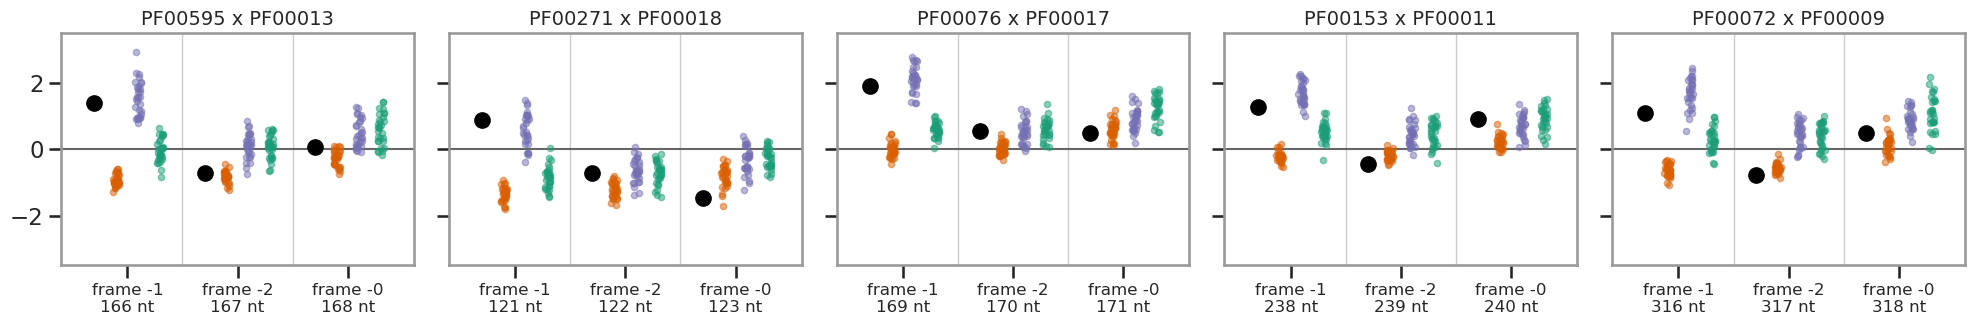

In [3]:
offset = {"standard": -0.30, "shuffled": -0.10, "permuted": 0.10, "scrambled": 0.30}
frameorder = [1, 2, 0]

def stripaxis(ax, d, title):
    overlaps = [o for f in frameorder
                for o in sorted(d[d["frame"] == f]["overlap"].unique())]
    for thistype in ["shuffled", "permuted", "scrambled", "standard"]:
        thisdat = d[d["code_type"] == thistype]
        for j, thisoverlap in enumerate(overlaps):
            vals = thisdat[thisdat["overlap"] == thisoverlap]["zscore_dist"].values
            if len(vals) == 0:
                continue
            if thistype == "standard":
                ax.plot([j + offset[thistype]] * len(vals), vals, ".",
                        color = codecolor[thistype], markersize = 22, zorder = 5)
            else:
                rng = np.random.default_rng(thisoverlap)
                ax.plot(j + offset[thistype] + rng.uniform(-0.03, 0.03, len(vals)), vals,
                        ".", color = codecolor[thistype], markersize = 9, alpha = 0.5,
                        zorder = 3)
    ax.axhline(0, color = '.4', linewidth = 1.5, zorder = 1)
    ax.grid(False)
    for x in np.arange(len(overlaps) - 1) + 0.5:
        ax.axvline(x, color = '.8', linewidth = 1, zorder = 0)
    ax.set_xticks(range(len(overlaps)))
    ax.set_xticklabels([f"frame -{o % 3}\n{o} nt" for o in overlaps], fontsize = 12)
    ax.set_xlim(-0.6, len(overlaps) - 0.4)
    ax.set_ylim(-3.5, 3.5)
    ax.set_title(title, fontsize = 14)

panels = [(n, df[df["pair"] == n]) for n in pairnames]
panels.append((fig5name, df[df["pair"] == fig5name]))

fig, axes = plt.subplots(1, len(panels), figsize = (20, 3.5), sharey = True)
for ax, (thisname, d) in zip(np.atleast_1d(axes), panels):
    stripaxis(ax, d, thisname)

ax0 = np.atleast_1d(axes)[0]
# ax0.set_ylabel("$z$ to front")
for thistype in ["standard", "shuffled", "permuted", "scrambled"]:
    ax0.plot([], [], ".", color = codecolor[thistype],
             markersize = 18 if thistype == "standard" else 10, label = codelabel[thistype])
# ax0.legend(fontsize = 11, loc = "upper right")
# fig.text(0.5, -0.04, "reading frame (overlap length)", ha = "center", fontsize = 15)

plt.tight_layout()
os.makedirs("Panels", exist_ok = True)
plt.savefig("Panels/results.svg", bbox_inches = "tight", dpi = 300)

In [4]:
# 